In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "src" else Path.cwd()

TABLES_DIR = PROJECT_ROOT / "data" / "modeling_datasets"
CONFIG_PATH = PROJECT_ROOT / "config" / "feature_columns.json"

AFIB_PATH = TABLES_DIR / "afib_features.parquet
ABNORM_PATH = TABLES_DIR / "abnorm_features.parquet"

print(AFIB_PATH)
print(ABNORM_PATH)
print(CONFIG_PATH)

/Users/silver/Desktop/DSC/180/ecg-signal-analysis/data/final_datasets/afib_features.parquet
/Users/silver/Desktop/DSC/180/ecg-signal-analysis/data/final_datasets/abnorm_features.parquet
/Users/silver/Desktop/DSC/180/ecg-signal-analysis/config/feature_columns.json


## Load Config and Datasets

In [3]:
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

afib_df = pd.read_parquet(AFIB_PATH)
abnorm_df = pd.read_parquet(ABNORM_PATH)

print("afib_df:", afib_df.shape)
print("abnorm_df:", abnorm_df.shape)
print(cfg)

afib_df: (9991, 585)
abnorm_df: (9988, 585)
{'embedding_prefix': 'emb_', 'embedding_dimension': 512, 'exclude_columns': ['subject_id', 'study_id', 'file_name', 'path', 'waveform_path', 'machine_report', 'label', 'ecg_time', 'is_af', 'is_normal_strict', 'is_clearly_abnormal']}


### Configure Data Features
A shared configuration file is used to define which columns should be excluded from modeling and how embedding features are identified. This prevents accidental inclusion of identifiers, timestamps, or metadata that could introduce data leakage or non-physiological signals into the model. Using a configuration file also ensures that feature selection logic remains consistent across experiments and future scripts.

In [4]:
def get_feature_groups(df, cfg):
    exclude = set(cfg["exclude_columns"])
    emb_prefix = cfg["embedding_prefix"]

    embedding_cols = [c for c in df.columns if c.startswith(emb_prefix)]
    signal_cols = [
        c for c in df.columns
        if c not in exclude and not c.startswith(emb_prefix)
    ]
    combined_cols = signal_cols + embedding_cols

    return signal_cols, embedding_cols, combined_cols

In [5]:
get_feature_groups(afib_df, cfg)

(['lead_mean_mean',
  'lead_mean_std',
  'lead_mean_min',
  'lead_mean_max',
  'lead_std_mean',
  'lead_std_std',
  'lead_std_min',
  'lead_std_max',
  'lead_min_mean',
  'lead_min_std',
  'lead_min_min',
  'lead_min_max',
  'lead_max_mean',
  'lead_max_std',
  'lead_max_min',
  'lead_max_max',
  'lead_ptp_mean',
  'lead_ptp_std',
  'lead_ptp_min',
  'lead_ptp_max',
  'lead_rms_mean',
  'lead_rms_std',
  'lead_rms_min',
  'lead_rms_max',
  'lead_energy_mean',
  'lead_energy_std',
  'lead_energy_min',
  'lead_energy_max',
  'dom_freq_mean',
  'dom_freq_std',
  'dom_freq_min',
  'dom_freq_max',
  'spec_entropy_mean',
  'spec_entropy_std',
  'spec_entropy_min',
  'spec_entropy_max',
  'spec_centroid_mean',
  'spec_centroid_std',
  'spec_centroid_min',
  'spec_centroid_max',
  'bp_0_5_5_mean',
  'bp_0_5_5_std',
  'bp_0_5_5_min',
  'bp_0_5_5_max',
  'bp_5_15_mean',
  'bp_5_15_std',
  'bp_5_15_min',
  'bp_5_15_max',
  'bp_15_40_mean',
  'bp_15_40_std',
  'bp_15_40_min',
  'bp_15_40_max',
  '

In [6]:
signal_cols, embedding_cols, combined_cols = get_feature_groups(afib_df, cfg)

print("signal features:", len(signal_cols))
print("embedding features:", len(embedding_cols))
print("combined features:", len(combined_cols))

signal features: 62
embedding features: 512
combined features: 574


In [7]:
print(afib_df["is_af"].value_counts(normalize=True))
print(abnorm_df["is_clearly_abnormal"].value_counts(normalize=True))

is_af
False    0.50015
True     0.49985
Name: proportion, dtype: float64
is_clearly_abnormal
False    0.5003
True     0.4997
Name: proportion, dtype: float64


## Logistic Regression Linear Baseline Experiment

### Evaluation Helpers
Multiple evaluation metrics are used to characterize classifier performance. AUROC is chosen as the primary metric because it measures the model’s ability to distinguish classes independent of a fixed decision threshold, which is particularly important in medical classification problems. Additional metrics such as F1-score, precision, recall, and accuracy provide complementary insights into class balance, false positive rates, and overall predictive reliability.

In [8]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "auroc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }

Logistic regression is used as the initial baseline model because it provides a strong yet interpretable linear classifier. Using a simple model helps isolate the effect of the feature representation itself, rather than improvements from the model itself. If embeddings outperform classical features under a linear model, it suggests that the learned representation organizes the ECG signal in a more linearly separable feature space.

In [9]:
def run_logistic_experiment(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=random_state
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = compute_metrics(y_test, y_prob)
    return model, metrics

In [10]:
X = afib_df[signal_cols]
y = afib_df["is_af"].astype(int)

model, metrics = run_logistic_experiment(X, y)
metrics

{'auroc': 0.9523853853853853,
 'f1': 0.8780732563973909,
 'precision': 0.8802816901408451,
 'recall': 0.8758758758758759,
 'accuracy': 0.8784392196098049}

In [11]:
def run_one_experiment(df, feature_cols, label_col, task_name, feature_type):
    X = df[feature_cols]
    y = df[label_col].astype(int)

    _, metrics = run_logistic_experiment(X, y)

    result = {
        "task": task_name,
        "feature_type": feature_type,
        "model": "Logistic Regression",
        "n_samples": len(df),
        "n_features": len(feature_cols),
        **metrics
    }
    return result

## Experiment Design
Each task is evaluated under three feature configurations: signal features only, HuBERT embeddings only, and the combined feature set. This means that we can isolate the contribution of learned ECG representations relative to traditional signal processing features. The combined dataset also tests whether signal processing features provide more information not captured by the pretrained embedding model.

The goal of the baseline experiments is not to achieve the highest possible performance but to evaluate the relative effectiveness of different ECG feature representations. By using a simple linear classifier across all feature sets, the experiments provide a controlled comparison between classical signal processing features and pretrained HuBERT embeddings, allowing the representation quality to be assessed independently of model complexity.

### AFIB Detection Task Trials

In [12]:
results = []

results.append(
    run_one_experiment(
        afib_df,
        signal_cols,
        "is_af",
        "AFIB Detection",
        "Signal"
    )
)

results.append(
    run_one_experiment(
        afib_df,
        embedding_cols,
        "is_af",
        "AFIB Detection",
        "HuBERT"
    )
)

results.append(
    run_one_experiment(
        afib_df,
        combined_cols,
        "is_af",
        "AFIB Detection",
        "Signal + HuBERT"
    )
)

### Abnormal ECG Classification Task Trials

In [13]:
results.append(
    run_one_experiment(
        abnorm_df,
        signal_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal"
    )
)

results.append(
    run_one_experiment(
        abnorm_df,
        embedding_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "HuBERT"
    )
)

results.append(
    run_one_experiment(
        abnorm_df,
        combined_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal + HuBERT"
    )
)

## XGBoost Non-linear Model Experiment

In [14]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def run_xgboost_experiment(X, y, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=random_state
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state
        ))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]

    metrics = compute_metrics(y_test, y_prob)

    return model, metrics

def run_xgb_experiment(df, feature_cols, label_col, task_name, feature_type):

    X = df[feature_cols]
    y = df[label_col].astype(int)

    _, metrics = run_xgboost_experiment(X, y)

    result = {
        "task": task_name,
        "feature_type": feature_type,
        "model": "XGBoost",
        "n_samples": len(df),
        "n_features": len(feature_cols),
        **metrics
    }

    return result

### AFIB Detection with XGBoost

In [15]:
results.append(
    run_xgb_experiment(
        afib_df,
        signal_cols,
        "is_af",
        "AFIB Detection",
        "Signal"
    )
)

results.append(
    run_xgb_experiment(
        afib_df,
        embedding_cols,
        "is_af",
        "AFIB Detection",
        "HuBERT"
    )
)

results.append(
    run_xgb_experiment(
        afib_df,
        combined_cols,
        "is_af",
        "AFIB Detection",
        "Signal + HuBERT"
    )
)

### Abnormal ECG Detection with XGBoost

In [16]:
results.append(
    run_xgb_experiment(
        abnorm_df,
        signal_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal"
    )
)

results.append(
    run_xgb_experiment(
        abnorm_df,
        embedding_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "HuBERT"
    )
)

results.append(
    run_xgb_experiment(
        abnorm_df,
        combined_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal + HuBERT"
    )
)

## Results

In [17]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["task","model","feature_type"]
).reset_index(drop=True)

results_df.round(4)

,task,feature_type,model,n_samples,n_features,auroc,f1,precision,recall,accuracy
0,AFIB Detection,HuBERT,Logistic Regression,9991,512,0.9970,0.9810,0.9819,0.9800,0.9810
1,AFIB Detection,Signal,Logistic Regression,9991,62,0.9524,0.8781,0.8803,0.8759,0.8784
2,AFIB Detection,Signal + HuBERT,Logistic Regression,9991,574,0.9985,0.9845,0.9830,0.9860,0.9845
3,AFIB Detection,HuBERT,XGBoost,9991,512,0.9955,0.9670,0.9670,0.9670,0.9670
4,AFIB Detection,Signal,XGBoost,9991,62,0.9872,0.9451,0.9336,0.9570,0.9445
5,AFIB Detection,Signal + HuBERT,XGBoost,9991,574,0.9976,0.9800,0.9809,0.9790,0.9800
6,Abnormal ECG Detection,HuBERT,Logistic Regression,9988,512,0.9678,0.9123,0.9348,0.8908,0.9144
7,Abnormal ECG Detection,Signal,Logistic Regression,9988,62,0.8845,0.8033,0.8403,0.7695,0.8118
8,Abnormal ECG Detection,Signal + HuBERT,Logistic Regression,9988,574,0.9664,0.9131,0.9377,0.8898,0.9154
9,Abnormal ECG Detection,HuBERT,XGBoost,9988,512,0.9536,0.8909,0.9154,0.8677,0.8939


In [18]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

results_df.to_csv(RESULTS_DIR / "baseline_logistic_results.csv", index=False)
results_df.to_parquet(RESULTS_DIR / "baseline_logistic_results.parquet", index=False)

print("Saved to:", RESULTS_DIR)

Saved to: /Users/silver/Desktop/DSC/180/ecg-signal-analysis/results


## 5 Fold Cross Validation for Logistic Regression

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

def make_logistic_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])

cv_scoring = {
    "auroc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy"
}

In [20]:
def run_logistic_cv(df, feature_cols, label_col, task_name, feature_type, n_splits=5, random_state=42):
    X = df[feature_cols]
    y = df[label_col].astype(int)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    model = make_logistic_pipeline()

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {
        "task": task_name,
        "feature_type": feature_type,
        "model": "Logistic Regression (5-fold CV)",
        "n_samples": len(df),
        "n_features": len(feature_cols),
        "auroc_mean": cv_results["test_auroc"].mean(),
        "auroc_std": cv_results["test_auroc"].std(),
        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),
        "precision_mean": cv_results["test_precision"].mean(),
        "precision_std": cv_results["test_precision"].std(),
        "recall_mean": cv_results["test_recall"].mean(),
        "recall_std": cv_results["test_recall"].std(),
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
    }

    return result

In [21]:
cv_results = []

# AFIB
cv_results.append(
    run_logistic_cv(
        afib_df,
        signal_cols,
        "is_af",
        "AFIB Detection",
        "Signal"
    )
)

cv_results.append(
    run_logistic_cv(
        afib_df,
        embedding_cols,
        "is_af",
        "AFIB Detection",
        "HuBERT"
    )
)

cv_results.append(
    run_logistic_cv(
        afib_df,
        combined_cols,
        "is_af",
        "AFIB Detection",
        "Signal + HuBERT"
    )
)

# Abnormal
cv_results.append(
    run_logistic_cv(
        abnorm_df,
        signal_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal"
    )
)

cv_results.append(
    run_logistic_cv(
        abnorm_df,
        embedding_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "HuBERT"
    )
)

cv_results.append(
    run_logistic_cv(
        abnorm_df,
        combined_cols,
        "is_clearly_abnormal",
        "Abnormal ECG Detection",
        "Signal + HuBERT"
    )
)

In [22]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(["task", "feature_type"]).reset_index(drop=True)
cv_results_df.round(4)

,task,feature_type,model,n_samples,n_features,auroc_mean,auroc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
0,AFIB Detection,HuBERT,Logistic Regression (5-fold CV),9991,512,0.9974,0.0009,0.9822,0.0029,0.9851,0.0023,0.9794,0.0042,0.9823,0.0029
1,AFIB Detection,Signal,Logistic Regression (5-fold CV),9991,62,0.9494,0.0024,0.8777,0.0057,0.8857,0.0076,0.8698,0.0072,0.8788,0.0057
2,AFIB Detection,Signal + HuBERT,Logistic Regression (5-fold CV),9991,574,0.9980,0.0005,0.9834,0.0027,0.9857,0.0029,0.9812,0.0037,0.9835,0.0027
3,Abnormal ECG Detection,HuBERT,Logistic Regression (5-fold CV),9988,512,0.9692,0.0021,0.9164,0.0044,0.9330,0.0067,0.9004,0.0051,0.9179,0.0044
4,Abnormal ECG Detection,Signal,Logistic Regression (5-fold CV),9988,62,0.9000,0.0016,0.8211,0.0051,0.8542,0.0043,0.7906,0.0106,0.8279,0.0039
5,Abnormal ECG Detection,Signal + HuBERT,Logistic Regression (5-fold CV),9988,574,0.9698,0.0018,0.9173,0.0044,0.9328,0.0061,0.9024,0.0079,0.9187,0.0043


In [23]:
cv_results_df.to_csv(RESULTS_DIR / "logistic_cv_results.csv", index=False)
cv_results_df.to_parquet(RESULTS_DIR / "logistic_cv_results.parquet", index=False)

print("Saved CV results to:", RESULTS_DIR)

Saved CV results to: /Users/silver/Desktop/DSC/180/ecg-signal-analysis/results


/var/folders/xn/jck3v4qd58xgkpg5jx9v99tm0000gn/T/ipykernel_70862/4189944260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


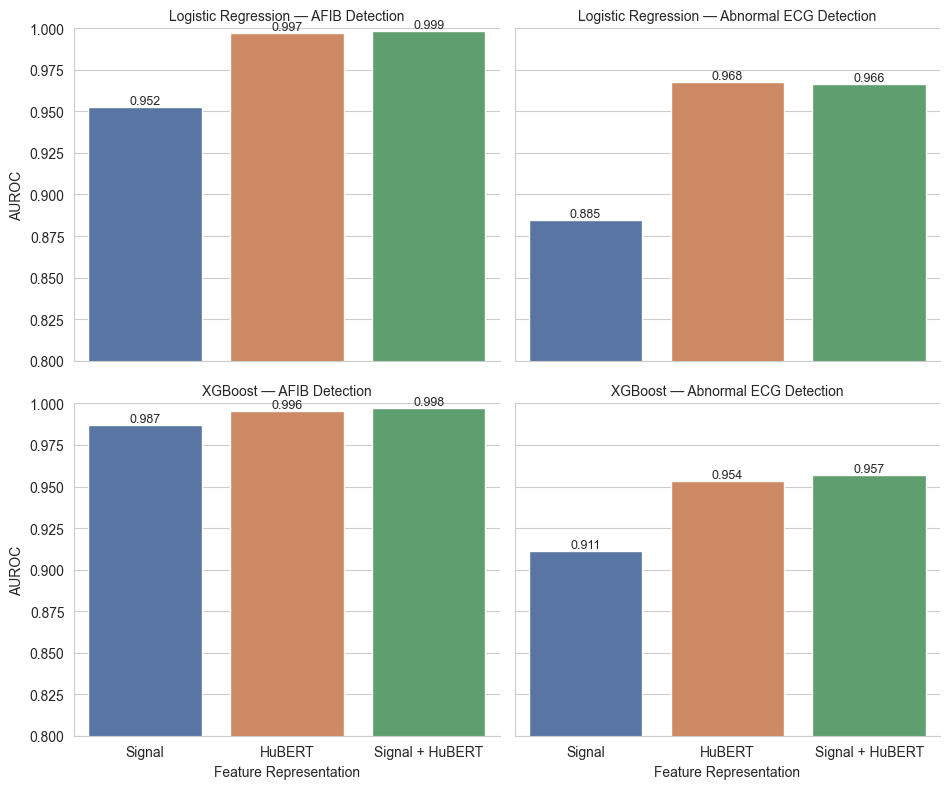

In [24]:
sns.set_style("whitegrid")

g = sns.catplot(
    data=results_df,
    x="feature_type",
    y="auroc",
    col="task",
    row="model",
    kind="bar",
    height=4,
    aspect=1.2,
    palette=["#4C72B0", "#DD8452", "#55A868"],
    order = ["Signal", "HuBERT", "Signal + HuBERT"]
)

g.set_axis_labels("Feature Representation", "AUROC")
g.set_titles("{row_name} — {col_name}")

# Add labels + adjust axis
for ax in g.axes.flatten():

    # tighten the y-axis range
    ax.set_ylim(0.8, 1.0)

    # label bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=9)


plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## ROC Curve Comparison

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

def get_logistic_roc_data(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=random_state
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)

    return {
        "fpr": fpr,
        "tpr": tpr,
        "auroc": auroc
    }

### Afib ROCs

In [26]:
afib_y = afib_df["is_af"].astype(int)

roc_afib_signal = get_logistic_roc_data(
    afib_df[signal_cols],
    afib_y
)

roc_afib_hubert = get_logistic_roc_data(
    afib_df[embedding_cols],
    afib_y
)

roc_afib_combined = get_logistic_roc_data(
    afib_df[combined_cols],
    afib_y
)

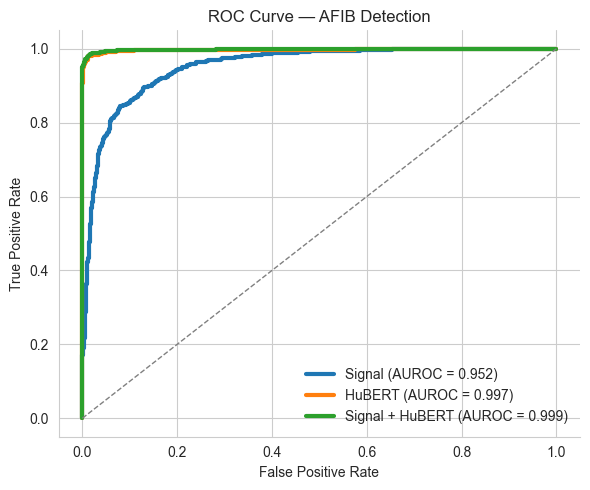

In [27]:
plt.figure(figsize=(6, 5))

plt.plot(
    roc_afib_signal["fpr"],
    roc_afib_signal["tpr"],
    label=f'Signal (AUROC = {roc_afib_signal["auroc"]:.3f})',
    linewidth=3
)

plt.plot(
    roc_afib_hubert["fpr"],
    roc_afib_hubert["tpr"],
    label=f'HuBERT (AUROC = {roc_afib_hubert["auroc"]:.3f})',
    linewidth=3
)

plt.plot(
    roc_afib_combined["fpr"],
    roc_afib_combined["tpr"],
    label=f'Signal + HuBERT (AUROC = {roc_afib_combined["auroc"]:.3f})',
    linewidth=3
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AFIB Detection")
plt.legend(frameon=False)
plt.tight_layout()

sns.despine()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "roc_afib_detection.png", dpi=300, bbox_inches="tight")
plt.show()

### Abnormal ECG ROCs

In [28]:
abnorm_y = abnorm_df["is_clearly_abnormal"].astype(int)

roc_abnorm_signal = get_logistic_roc_data(
    abnorm_df[signal_cols],
    abnorm_y
)

roc_abnorm_hubert = get_logistic_roc_data(
    abnorm_df[embedding_cols],
    abnorm_y
)

roc_abnorm_combined = get_logistic_roc_data(
    abnorm_df[combined_cols],
    abnorm_y
)

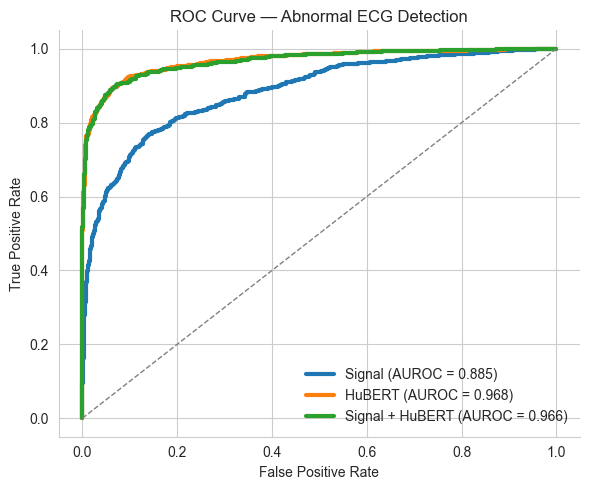

In [29]:
plt.figure(figsize=(6, 5))

plt.plot(
    roc_abnorm_signal["fpr"],
    roc_abnorm_signal["tpr"],
    label=f'Signal (AUROC = {roc_abnorm_signal["auroc"]:.3f})',
    linewidth=3
)

plt.plot(
    roc_abnorm_hubert["fpr"],
    roc_abnorm_hubert["tpr"],
    label=f'HuBERT (AUROC = {roc_abnorm_hubert["auroc"]:.3f})',
    linewidth=3
)

plt.plot(
    roc_abnorm_combined["fpr"],
    roc_abnorm_combined["tpr"],
    label=f'Signal + HuBERT (AUROC = {roc_abnorm_combined["auroc"]:.3f})',
    linewidth=3
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Abnormal ECG Detection")
plt.legend(frameon=False)
plt.tight_layout()

sns.despine()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "roc_abnorm_detection.png", dpi=300, bbox_inches="tight")
plt.show()

## PCA

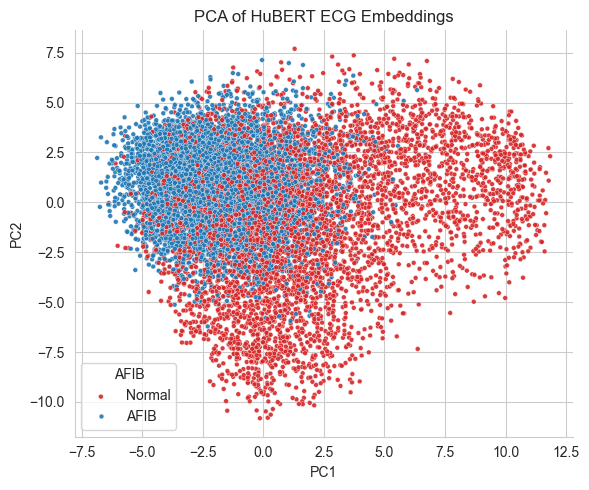

In [30]:
from sklearn.decomposition import PCA

X = afib_df[embedding_cols].values
y = afib_df["is_af"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=afib_df["is_af"],
    palette=["#1f77b4","#d62728"],
    alpha=0.9,
    s=12
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of HuBERT ECG Embeddings")

plt.legend(title="AFIB", labels=["Normal", "AFIB"])
sns.despine()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "pca_hubert_ecg.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

## UMAP Visualization of HuBERT Embeddings

In [31]:
import umap

X = afib_df[embedding_cols].values
y = afib_df["is_af"].astype(int).map({0: "Normal", 1: "AFIB"})

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=67
)

X_umap = reducer.fit_transform(X)

plot_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": y
})

print(plot_df["label"].value_counts(dropna=False))

/Users/silver/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


label
Normal    4997
AFIB      4994
Name: count, dtype: int64


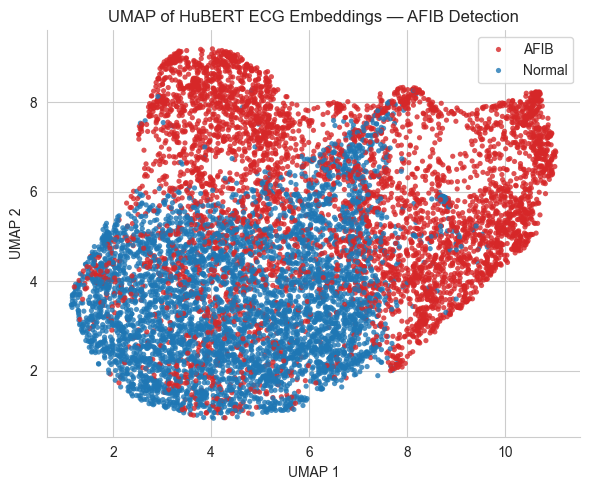

In [32]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="label",
    palette={"Normal": "#1f77b4", "AFIB": "#d62728"},
    alpha=0.8,
    s=14,
    linewidth=0
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of HuBERT ECG Embeddings — AFIB Detection")

plt.legend(title="")
sns.despine()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "umap_hubert_afib.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
X = abnorm_df[embedding_cols].values
y = abnorm_df["is_clearly_abnormal"].astype(int).map({0: "Normal", 1: "Abnormal"})

X_umap = reducer.fit_transform(X)

plot_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": y
})

print(plot_df["label"].value_counts(dropna=False))

label
Normal      4997
Abnormal    4991
Name: count, dtype: int64


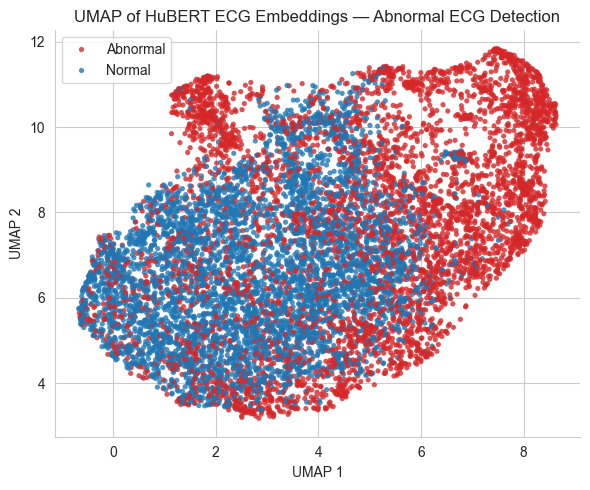

In [34]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="label",
    palette={"Normal": "#1f77b4", "Abnormal": "#d62728"},
    alpha=0.8,
    s=14,
    linewidth=0
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of HuBERT ECG Embeddings — Abnormal ECG Detection")

plt.legend(title="")
sns.despine()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "umap_hubert_abnorm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Signal Importance

In [35]:
X = afib_df[signal_cols]
y = afib_df["is_af"].astype(int)

xgb_model_afib_signal, afib_signal_metrics = run_xgboost_experiment(X, y)
afib_signal_metrics

{'auroc': 0.9872252252252252,
 'f1': 0.9451309935739002,
 'precision': 0.93359375,
 'recall': 0.9569569569569569,
 'accuracy': 0.9444722361180591}

In [36]:
importance_df = pd.DataFrame({
    "feature": signal_cols,
    "importance": xgb_model_afib_signal.named_steps["clf"].feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
58,rmssd,0.215303
36,spec_centroid_mean,0.051325
60,rr_range,0.048712
1,lead_mean_std,0.036913
30,dom_freq_min,0.036123
48,bp_15_40_mean,0.031610
35,spec_entropy_max,0.025164
31,dom_freq_max,0.024562
45,bp_5_15_std,0.023839
32,spec_entropy_mean,0.023713


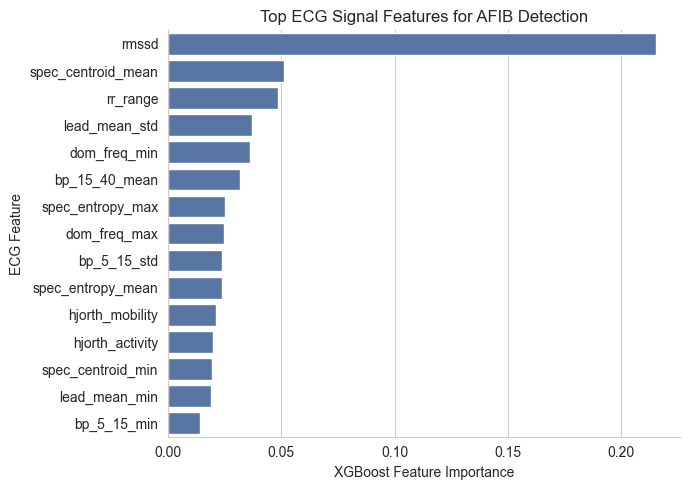

In [37]:
top_features = importance_df.head(15)

plt.figure(figsize=(7,5))

sns.barplot(
    data=top_features,
    y="feature",
    x="importance",
    color="#4C72B0"
)

plt.title("Top ECG Signal Features for AFIB Detection")
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("ECG Feature")

sns.despine()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "signal_feature_importance_afib.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
X = abnorm_df[signal_cols]
y = abnorm_df["is_clearly_abnormal"].astype(int)

xgb_model_abnorm_signal, abnorm_signal_metrics = run_xgboost_experiment(X, y)
abnorm_signal_metrics

{'auroc': 0.9113476953907815,
 'f1': 0.8264887063655031,
 'precision': 0.8473684210526315,
 'recall': 0.8066132264529058,
 'accuracy': 0.8308308308308309}

In [39]:
importance_df = pd.DataFrame({
    "feature": signal_cols,
    "importance": xgb_model_abnorm_signal.named_steps["clf"].feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
32,spec_entropy_mean,0.152291
22,lead_rms_min,0.035036
59,heart_rate_bpm,0.033625
52,hjorth_activity,0.032982
8,lead_min_mean,0.032458
36,spec_centroid_mean,0.028353
6,lead_std_min,0.026235
48,bp_15_40_mean,0.026032
56,rr_mean,0.025688
60,rr_range,0.023918


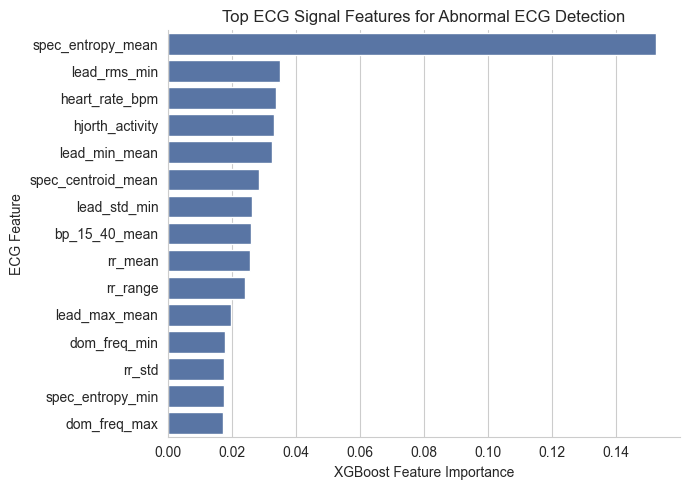

In [40]:
top_features = importance_df.head(15)

plt.figure(figsize=(7,5))

sns.barplot(
    data=top_features,
    y="feature",
    x="importance",
    color="#4C72B0"
)

plt.title("Top ECG Signal Features for Abnormal ECG Detection")
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("ECG Feature")

sns.despine()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "signal_feature_importance_abnorm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()